# **Practical: Convolutional Neural Networks**

This Practical covers fundamental CNN development, training and testing.


### **Exercise 1: Implementing and training a CNN for an image classification problem from scratch**

 the simple MNIST dataset will be used to train and test a simple convolutional neural network. Try with different numbers of network layers.

In [1]:
import torch
import torch.nn as nn


class SimpleCNN(nn.Module):
    
    def __init__(self, channels=1):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, 8, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(8 * 13 * 13, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x

model = SimpleCNN()
print(model)

SimpleCNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1352, out_features=10, bias=True)
)


This is the structure of our neural network (a CNN: Convolutional Neural Network). The model consists of several layers that process the image step by step to determine which digit it represents.

The first layer is Conv2d(1, 8, kernel_size=(3, 3)). This means we start with 1 input channel (the grayscale image), and the layer uses 8 filters. Each filter looks at small regions of the image (3×3 pixels) and tries to detect patterns such as edges or simple shapes.

You can choose how many filters you want to use in a convolutional layer.

At the start of training, the filters do not yet have any meaning — they consist of random values. During training, the model learns which values these filters should have in order to detect useful patterns.

You can think of it like this:

The number of filters (8) determines how many different patterns the model can learn at the same time
The content of those filters is learned during training; they start with random values and gradually adapt to recognize important patterns

Using more filters allows the model to detect a wider variety of features (such as edges, corners, and shapes), but it also makes the model larger and slower.

Next, we have MaxPool2d(kernel_size=2, stride=2). This layer reduces the size of the image by taking the maximum value from each 2×2 block of pixels. This keeps the most important information while making the representation more compact and efficient to process.

Then we have Linear(in_features=1352, out_features=10). Before this layer is applied, the data is flattened into a single long vector of 1352 values. This layer is a standard fully connected layer that uses these values to compute 10 output scores.

These 10 values correspond to the digits 0 through 9. The model assigns a score to each digit, and the digit with the highest score is the final prediction.

In short: the model first looks for small patterns in the image (convolution), then reduces the size of the data (pooling), and finally uses a standard neural network layer to decide which digit it is.

## Visualisation of filters

Let's take a look at the filtgers of the first convolutional layer:

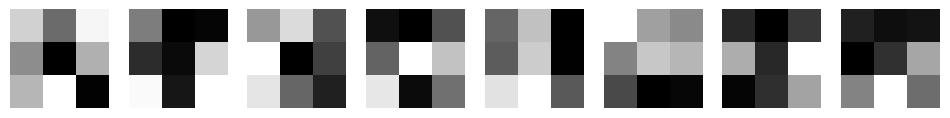

In [2]:
import matplotlib.pyplot as plt
filters = model.conv1.weight.data

fig, axes = plt.subplots(1, 8, figsize=(12,3))
for i in range(8):
    axes[i].imshow(filters[i][0], cmap='gray')
    axes[i].axis('off')
plt.show()

## Time to train the model.

Lets create functions to train and test:

In [3]:
import torch.optim as optim
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)

lr = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=lr)


def train(model, loader, criterion, optimizer, device):
    model.train() # Zet het model in training modus
    running_loss = 0.0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad() # Reset de gradients
        outputs = model(images)
        loss = criterion(outputs, labels) # Bereken de loss
        loss.backward() # Bereken de gradients
        optimizer.step() # Update de model parameters

        running_loss += loss.item() # Accumuleer de loss

    return running_loss / len(loader) # Gemiddelde loss per batch


def test(model, loader, criterion, device):
    model.eval() # Zet het model in evaluatie modus
    correct = 0
    total = 0
    running_loss = 0.0

    with torch.no_grad(): # Geen gradients nodig tijdens evaluatie
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1) # Krijg de voorspelde klasse

            total += labels.size(0) # Tel het aantal voorbeelden
            correct += (predicted == labels).sum().item() # Tel het aantal correcte voorspellingen

    accuracy = 100 * correct / total # Bereken de nauwkeurigheid
    avg_loss = running_loss / len(loader)
    
    return avg_loss, accuracy


## Training

Let's go: get the dataset.

In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
transform = transforms.ToTensor()

batch_size = 64

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


create a funtion to train the model:

In [5]:
import time

def train_model(model, train_loader, test_loader, criterion, optimizer, device, epochs=10):
    train_losses = []
    test_losses  = []
    test_accs    = []

    print('start training...')
    start_time = time.time()
    for epoch in range(epochs):
        print(f"Epoch {epoch+1}/{epochs}")
        
        train_loss = train(model, train_loader, criterion, optimizer, device)
        print(f"Train Loss: {train_loss:.4f}")
        test_loss, test_acc = test(model, test_loader, criterion, device)
        print(f"Test Loss:  {test_loss:.4f} | Test Acc: {test_acc:.2f}%")
        
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        test_accs.append(test_acc)

    print(f"--- training time: {time.time() - start_time} seconds ---" )
    
    return train_losses, test_losses, test_accs

def print_results(train_losses, test_losses, test_accs):
    fig,axs = plt.subplots(1,2, figsize= (10, 5))
    axs[0].plot(train_losses, color='blue')
    axs[0].plot(test_losses, color='red')
    axs[0].legend(['Train Loss', 'Test Loss'], loc='upper right')
    axs[0].set_xlabel('Iteration')
    axs[0].set_ylabel('Negative log likelihood loss')


    axs[1].plot(test_accs, color='red')
    axs[1].legend(['Test accuracy'], loc='upper right')
    axs[1].set_xlabel('Iteration')
    axs[1].set_ylabel('Accuracy')
    

In [6]:
train_losses, test_losses, test_accs = train_model(model, train_loader, test_loader, 
                                                   criterion, optimizer, device, 10)

start training...
Epoch 1/10
Train Loss: 0.3821
Test Loss:  0.1784 | Test Acc: 94.91%
Epoch 2/10
Train Loss: 0.1557
Test Loss:  0.1186 | Test Acc: 96.43%
Epoch 3/10
Train Loss: 0.1159
Test Loss:  0.0969 | Test Acc: 97.16%
Epoch 4/10
Train Loss: 0.0953
Test Loss:  0.0875 | Test Acc: 97.44%
Epoch 5/10
Train Loss: 0.0823
Test Loss:  0.0765 | Test Acc: 97.55%
Epoch 6/10
Train Loss: 0.0722
Test Loss:  0.0748 | Test Acc: 97.66%
Epoch 7/10
Train Loss: 0.0646
Test Loss:  0.0738 | Test Acc: 97.55%
Epoch 8/10
Train Loss: 0.0590
Test Loss:  0.0705 | Test Acc: 97.76%
Epoch 9/10
Train Loss: 0.0535
Test Loss:  0.0626 | Test Acc: 98.03%
Epoch 10/10
Train Loss: 0.0495
Test Loss:  0.0609 | Test Acc: 98.01%
--- training time: 163.97459626197815 seconds ---


Let's plot the trainings details:

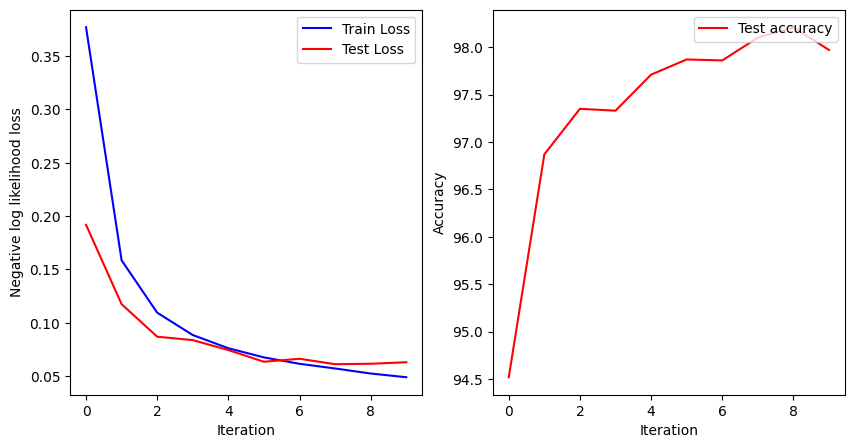

In [7]:
print_results(train_losses, test_losses, test_accs)

In [7]:
batch_size = 64
learning_rate = 0.001

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

filters = 8

class SimpleCNN(nn.Module):
    
    def __init__(self, channels=3):
        super().__init__()
        self.conv1 = nn.Conv2d(channels, filters, kernel_size=3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(filters * 111 * 111, 102)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)
        x = self.fc1(x)
        return x


train_dataset = datasets.Flowers102('./data', split='train', download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)

test_dataset =   datasets.Flowers102('./data', split='test', download=True, transform=transform)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

start training...
Epoch 1/10
Train Loss: 25.6544
Test Loss:  9.1224 | Test Acc: 2.10%
Epoch 2/10
Train Loss: 5.1782
Test Loss:  4.5759 | Test Acc: 6.03%
Epoch 3/10
Train Loss: 4.4449
Test Loss:  4.3000 | Test Acc: 6.93%
Epoch 4/10
Train Loss: 3.3105
Test Loss:  4.1333 | Test Acc: 11.35%
Epoch 5/10
Train Loss: 2.2770
Test Loss:  4.0710 | Test Acc: 14.69%
Epoch 6/10
Train Loss: 1.1699
Test Loss:  4.2603 | Test Acc: 14.21%
Epoch 7/10
Train Loss: 0.6062
Test Loss:  4.1975 | Test Acc: 13.79%
Epoch 8/10
Train Loss: 0.2250
Test Loss:  4.3767 | Test Acc: 14.39%
Epoch 9/10
Train Loss: 0.1321
Test Loss:  4.5794 | Test Acc: 13.01%
Epoch 10/10
Train Loss: 0.0616
Test Loss:  4.4781 | Test Acc: 14.57%
--- training time: 989.666223526001 seconds ---


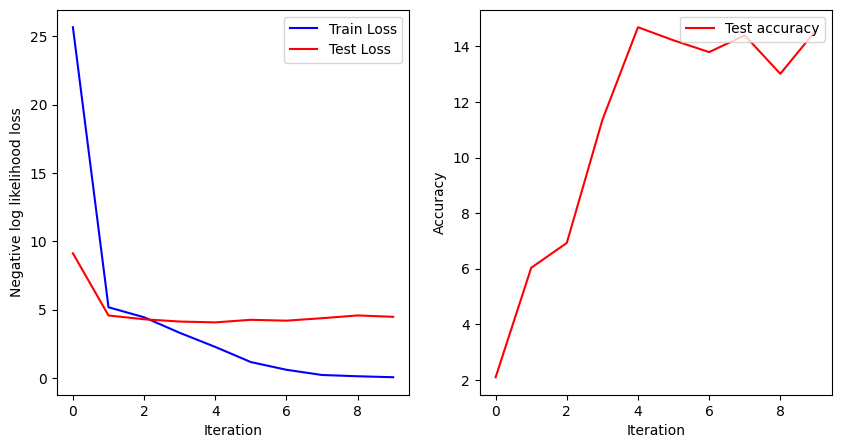

In [9]:
epochs = 10

model = SimpleCNN(3).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses, test_accs = train_model(model, train_loader, test_loader, 
                                                   criterion, optimizer, device, epochs)
print_results(train_losses, test_losses, test_accs)

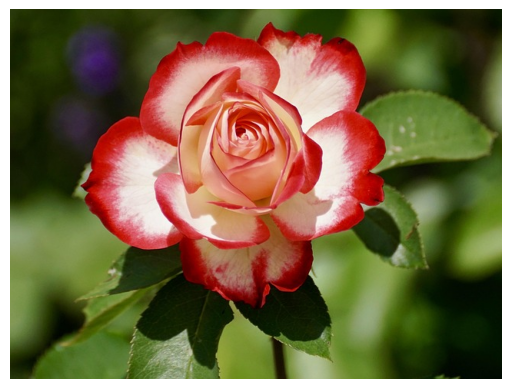

In [10]:
from PIL import Image
image = Image.open("rose.jpg").convert("RGB")
plt.imshow(image)
plt.axis("off")
plt.show()

In [11]:
transform_image = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image = transform_image(image)
image = image.unsqueeze(0)  # batch dimension toevoegen
image = image.to(device)

with torch.no_grad():
    outputs = model(image)
    _, predicted = torch.max(outputs, 1)
    label = predicted.item()
    print("Predicted label:", label)

Predicted label: 17


This is not really a good score. We are trying to improve this by using Transfer Learning. 

## **Exercise 2: Transfer learning using architectures trained on ImageNet**

A deep network pretrained on ImageNet will be loaded. This model is trained on a lot ob object oriented images.-

#### **- loading a pretrained model from TorchVision**

In [8]:
from torchvision.models import resnet50

# Using pretrained weights:
res_network  = resnet50(pretrained=True)

print(res_network)

c:\Users\Marjolein\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\Marjolein\AppData\Local\Programs\Python\Python312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [9]:
# check the last layer
print(type(res_network.fc))
print(res_network.fc.in_features)

<class 'torch.nn.modules.linear.Linear'>
2048


In [10]:
# change last fc layer
res_network.fc = torch.nn.Linear(in_features=2048, out_features=102)

# freezing layers
print('freezing layers...')
for param in res_network.layer1.parameters(): 
    param.requires_grad = False
for param in res_network.layer2.parameters():
    param.requires_grad = False
for param in res_network.layer3.parameters():
    param.requires_grad = False
for param in res_network.layer4.parameters():
    param.requires_grad = False
print('freezed!')

freezing layers...
freezed!


In [11]:

batch_size = 64
learning_rate = 0.001

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

train_dataset = datasets.Flowers102('./data', split='train', download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size)

test_dataset =   datasets.Flowers102('./data', split='test', download=True, transform=transform)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print('model trained on Flowers102 and tested on Fashion Flowers102:')
optimizer = optim.Adam(res_network.parameters(), lr=learning_rate)




model trained on Flowers102 and tested on Fashion Flowers102:


In [12]:
epochs = 3
model = res_network.to(device)
train_losses, test_losses, test_accs = train_model(model, train_loader, test_loader, 
                                                   criterion, optimizer, device, epochs)
print_results(train_losses, test_losses, test_accs)

start training...
Epoch 1/3


: 

Let's see if we can improve this by unfreezing layers:

In [ ]:
res_network  = resnet50(pretrained=True)

# freezing layers
print('unfreezing layers...')
for param in res_network.layer1.parameters(): 
    param.requires_grad = False
for param in res_network.layer2.parameters():
    param.requires_grad = False
for param in res_network.layer3.parameters():
    param.requires_grad = True
for param in res_network.layer4.parameters():
    param.requires_grad = True


And train again:

In [ ]:
epochs = 10

model = res_network.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

train_losses, test_losses, test_accs = train_model(model, train_loader, test_loader, 
                                                   criterion, optimizer, device, epochs)
print_results(train_losses, test_losses, test_accs)